In [1]:
import pandas as pd

# 1. Gộp dữ liệu
df_req = pd.read_csv('Requests_min -data-2026-07-08 15_38_43.csv')
df_p95 = pd.read_csv('P95 Response Time (ms)-data-2026-07-08 15_38_57.csv')
df_cpu = pd.read_csv('CPU %-data-2026-07-08 15_38_50.csv')

# Đổi tên cột cho dễ xử lý
df_req.columns = ['Time', 'Requests']
df_p95.columns = ['Time', 'P95_RT']
df_cpu.columns = ['Time', 'CPU_Usage']

# Merge theo cột Time
master_df = pd.merge(df_req, df_p95, on='Time')
master_df = pd.merge(master_df, df_cpu, on='Time')

# 2. Làm sạch (loại bỏ dòng có giá trị rỗng/NaN)
master_df = master_df.dropna()

# 3. Lưu lại
master_df.to_csv('master_dataset1.csv', index=False)
print("Đã tạo xong file master_dataset1.csv sẵn sàng để mô hình hóa!")
print(master_df.head())

Đã tạo xong file master_dataset1.csv sẵn sàng để mô hình hóa!
                  Time  Requests  P95_RT  CPU_Usage
1  2026-07-07 19:46:00      87.3    50.6       5.86
2  2026-07-07 19:47:00     184.0    46.0      11.80
3  2026-07-07 19:48:00     272.0    59.0      18.30
4  2026-07-07 19:49:00     367.0    46.1      24.40
5  2026-07-07 19:50:00     445.0    45.2      29.10


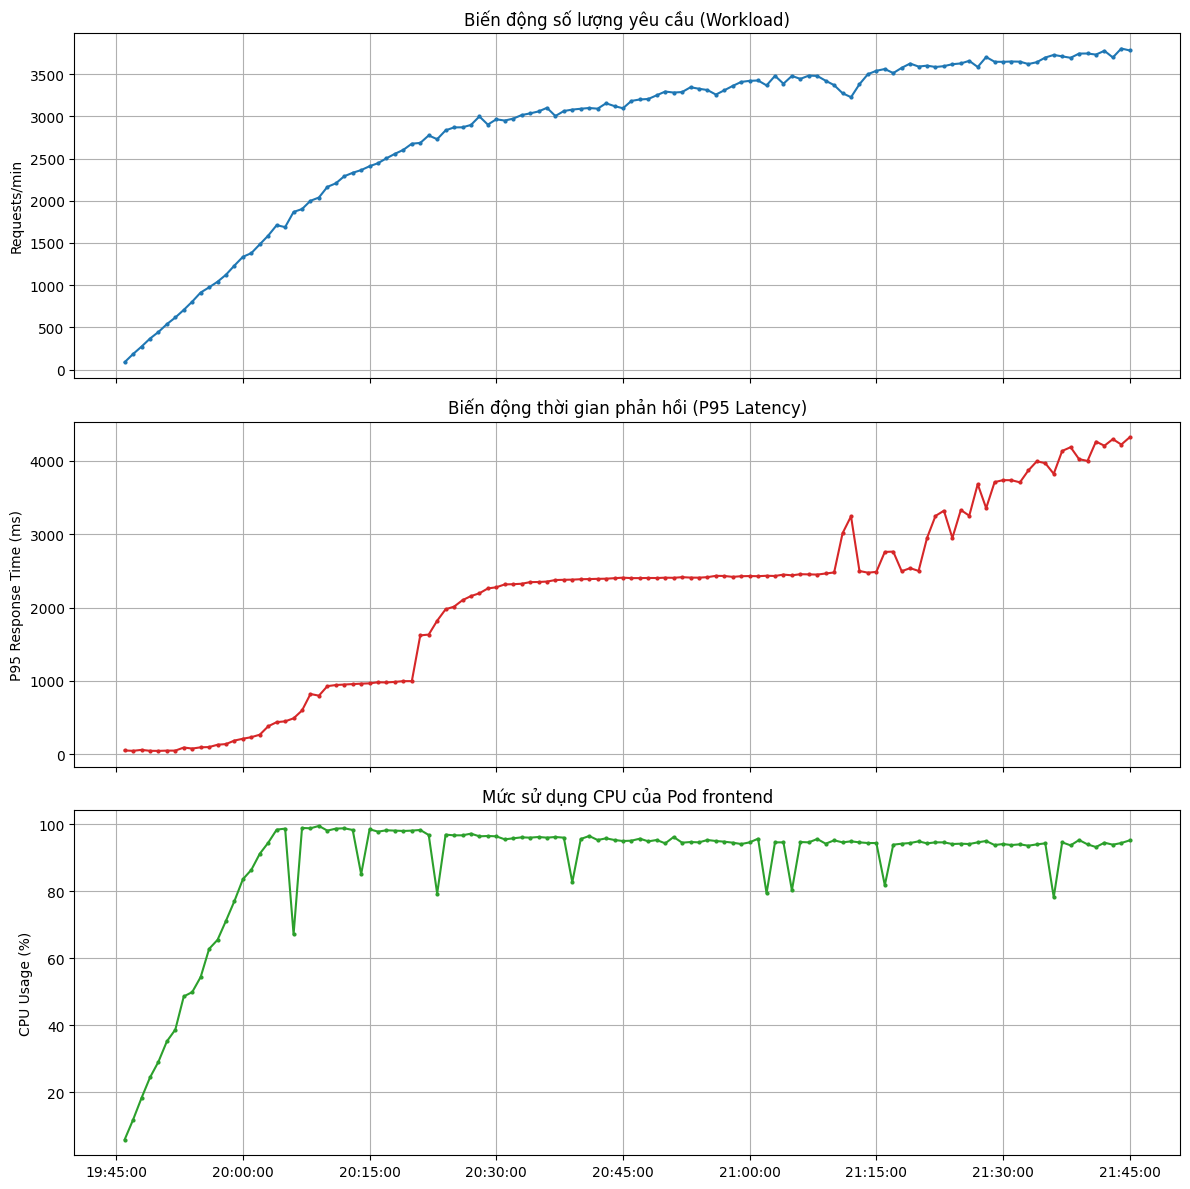

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Đọc dữ liệu
master_df = pd.read_csv('master_dataset1.csv')
master_df['Time'] = pd.to_datetime(master_df['Time'])

# 2. Tạo layout
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# 3. Vẽ dữ liệu (giữ lại Time ở trục X)
ax1.plot(master_df['Time'], master_df['Requests'], color='tab:blue', marker='o', markersize=2)
ax1.set_ylabel('Requests/min')
ax1.set_title('Biến động số lượng yêu cầu (Workload)')
ax1.grid(True)

ax2.plot(master_df['Time'], master_df['P95_RT'], color='tab:red', marker='o', markersize=2)
ax2.set_ylabel('P95 Response Time (ms)')
ax2.set_title('Biến động thời gian phản hồi (P95 Latency)')
ax2.grid(True)

ax3.plot(master_df['Time'], master_df['CPU_Usage'], color='tab:green', marker='o', markersize=2)
ax3.set_ylabel('CPU Usage (%)')
ax3.set_title('Mức sử dụng CPU của Pod frontend')
ax3.grid(True)

# 4. Format lại trục X để chỉ hiển thị HH:MM:SS
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
# plt.xticks(rotation=45) # Xoay chữ để không bị đè lên nhau

plt.tight_layout()
plt.show()